# Game Analytics Notebook

Use this notebook to replay the trained RL policy on the fixed 100-mission manifest and inspect what the model actually does.

It visualizes:
- missions completed per type
- success / partial / unresolved outcomes per mission type
- which aircraft were used for what
- loadout matching quality
- fuel, weapons, and spare-parts consumption
- base usage and transfer patterns
- maintenance impact and aircraft availability
- a mission timeline for one episode


In [1]:
from __future__ import annotations

from pathlib import Path
import json
import re
import sys

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from fleet_env import FleetEnv
from sb3_contrib import MaskablePPO

CONFIG_PATH = PROJECT_ROOT / "config.yml"
MISSIONS_FILE = PROJECT_ROOT / "generated_missions_100.json"
MODELS_ROOT = PROJECT_ROOT / "models"

# Leave this as None to auto-pick the best replay performer.
# Example override:
# SELECTED_RUN_NAME = "hackathon_sweep_20260315_184726_balanced_baseline_seed42"
SELECTED_RUN_NAME = None

SEEDS = [42, 43, 44]
TIMELINE_SEED = SEEDS[0]
DETERMINISTIC = True

config = yaml.safe_load(CONFIG_PATH.read_text(encoding="utf-8"))
MISSION_ORDER = [profile["name"] for profile in config["missions"]["profiles"].values()]
COLOR_PALETTE = ["#4C78A8", "#59A14F", "#F28E2B", "#E15759", "#B07AA1", "#76B7B2"]
MISSION_COLORS = {
    mission_name: COLOR_PALETTE[idx % len(COLOR_PALETTE)]
    for idx, mission_name in enumerate(MISSION_ORDER)
}

def relative_path(path: Path) -> str:
    return str(path.relative_to(PROJECT_ROOT))


def extract_seed(run_name: str) -> int | None:
    match = re.search(r"_seed(\d+)$", run_name)
    return int(match.group(1)) if match else None


def discover_balanced_baseline_runs() -> list[dict]:
    runs = []
    for run_dir in sorted(MODELS_ROOT.glob("*balanced_baseline_seed*")):
        if not run_dir.is_dir():
            continue

        model_path = run_dir / "best_model" / "best_model.zip"
        if not model_path.exists():
            fallback_model_path = run_dir / "final_model.zip"
            if fallback_model_path.exists():
                model_path = fallback_model_path
            else:
                continue

        run_info = {
            "run_name": run_dir.name,
            "training_seed": extract_seed(run_dir.name),
            "run_dir": run_dir,
            "model_path": model_path,
            "saved_eval_mean_reward": np.nan,
            "saved_eval_std_reward": np.nan,
            "saved_metric_source": "none",
        }

        summary_path = run_dir / "training_summary.json"
        if summary_path.exists():
            summary = json.loads(summary_path.read_text(encoding="utf-8"))
            run_info["saved_eval_mean_reward"] = float(summary.get("eval_mean_reward", np.nan))
            run_info["saved_eval_std_reward"] = float(summary.get("eval_std_reward", np.nan))
            run_info["saved_metric_source"] = "training_summary.json"
        else:
            eval_path = run_dir / "eval" / "evaluations.npz"
            if eval_path.exists():
                with np.load(eval_path) as eval_data:
                    final_eval_rewards = eval_data["results"][-1]
                run_info["saved_eval_mean_reward"] = float(np.mean(final_eval_rewards))
                run_info["saved_eval_std_reward"] = float(np.std(final_eval_rewards, ddof=0))
                run_info["saved_metric_source"] = "eval/evaluations.npz"

        runs.append(run_info)

    return runs


MODEL_RUNS = discover_balanced_baseline_runs()
assert CONFIG_PATH.exists(), f"Missing config file: {CONFIG_PATH}"
assert MISSIONS_FILE.exists(), f"Missing missions file: {MISSIONS_FILE}"
assert MODEL_RUNS, "No balanced_baseline model checkpoints were found under ./models."

MODEL_INDEX_DF = (
    pd.DataFrame(
        [
            {
                "run_name": run["run_name"],
                "training_seed": run["training_seed"],
                "saved_eval_mean_reward": run["saved_eval_mean_reward"],
                "saved_eval_std_reward": run["saved_eval_std_reward"],
                "saved_metric_source": run["saved_metric_source"],
                "model_path": relative_path(run["model_path"]),
            }
            for run in MODEL_RUNS
        ]
    )
    .sort_values(["saved_eval_mean_reward", "training_seed"], ascending=[False, True], na_position="last")
    .reset_index(drop=True)
)

preview_env = FleetEnv(CONFIG_PATH, mission_manifest_path=MISSIONS_FILE)
preview_env.reset(seed=SEEDS[0])
AIRCRAFT_ORDER = [preview_env.fleet[aid].name for aid in sorted(preview_env.fleet)]
BASE_ORDER = [preview_env.bases[bid].name for bid in sorted(preview_env.bases)]
del preview_env

print(f"Config: {CONFIG_PATH}")
print(f"Mission manifest: {MISSIONS_FILE}")
print(f"Discovered balanced_baseline runs: {len(MODEL_RUNS)}")
print(f"Replay seeds: {SEEDS}")
display(
    MODEL_INDEX_DF.style.format(
        {
            "saved_eval_mean_reward": "{:.2f}",
            "saved_eval_std_reward": "{:.2f}",
        },
        na_rep="n/a",
    )
)


Config: /Users/hello/Desktop/SAAB Hackathon/smartairbase/reinforcement_project/config.yml
Mission manifest: /Users/hello/Desktop/SAAB Hackathon/smartairbase/reinforcement_project/generated_missions_100.json
Discovered balanced_baseline runs: 3
Replay seeds: [42, 43, 44]


,run_name,training_seed,saved_eval_mean_reward,saved_eval_std_reward,saved_metric_source,model_path
0,hackathon_sweep_20260315_184726_balanced_baseline_seed42,42,63.33,3.13,training_summary.json,models/hackathon_sweep_20260315_184726_balanced_baseline_seed42/best_model/best_model.zip
1,hackathon_sweep_20260315_184726_balanced_baseline_seed999,999,60.83,7.52,eval/evaluations.npz,models/hackathon_sweep_20260315_184726_balanced_baseline_seed999/best_model/best_model.zip
2,hackathon_sweep_20260315_184726_balanced_baseline_seed123,123,59.50,4.31,training_summary.json,models/hackathon_sweep_20260315_184726_balanced_baseline_seed123/best_model/best_model.zip


In [2]:
def run_episode(model: MaskablePPO, seed: int) -> dict:
    env = FleetEnv(
        CONFIG_PATH,
        mission_manifest_path=MISSIONS_FILE,
        record_events=True,
    )
    obs, info = env.reset(seed=seed)
    total_reward = 0.0
    steps = 0

    while True:
        action, _ = model.predict(
            obs,
            deterministic=DETERMINISTIC,
            action_masks=env.action_masks(),
        )
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        if terminated or truncated:
            result = {
                "seed": seed,
                "reward": float(total_reward),
                "steps": steps,
                "terminated": bool(terminated),
                "truncated": bool(truncated),
                "missions_completed": int(env.missions_completed),
                "episode_hours": float(env.current_time),
                "events": env.episode_events,
            }
            env.close()
            return result


def summarize_episode_runs(episode_runs: list[dict]) -> dict:
    episode_summary_df = pd.DataFrame(
        [{key: value for key, value in run.items() if key != "events"} for run in episode_runs]
    )
    return {
        "reward_mean": float(episode_summary_df["reward"].mean()),
        "reward_std": float(episode_summary_df["reward"].std(ddof=0)),
        "missions_completed_mean": float(episode_summary_df["missions_completed"].mean()),
        "missions_completed_std": float(episode_summary_df["missions_completed"].std(ddof=0)),
        "episode_hours_mean": float(episode_summary_df["episode_hours"].mean()),
        "steps_mean": float(episode_summary_df["steps"].mean()),
        "termination_rate": float(episode_summary_df["terminated"].mean()),
        "truncation_rate": float(episode_summary_df["truncated"].mean()),
    }


def replay_model(run_info: dict, seeds: list[int]) -> dict:
    replay_model = MaskablePPO.load(str(run_info["model_path"]))
    episode_runs = [run_episode(replay_model, seed) for seed in seeds]
    return {
        "run_name": run_info["run_name"],
        **summarize_episode_runs(episode_runs),
    }


def consumed_weapon_total(payload: dict) -> int:
    if not isinstance(payload, dict):
        return 0
    return int(sum(int(quantity) for quantity in payload.values()))


def build_analysis_frames(model: MaskablePPO, seeds: list[int]):
    episode_runs = [run_episode(model, seed) for seed in seeds]

    event_rows = []
    for run in episode_runs:
        for event in run["events"]:
            event_rows.append({"episode_seed": run["seed"], **event})

    events_df = pd.DataFrame(event_rows)
    episode_summary_df = pd.DataFrame(
        [{key: value for key, value in run.items() if key != "events"} for run in episode_runs]
    )

    mission_offered_df = events_df[events_df["event_type"] == "mission_offered"].copy()
    mission_exec_df = events_df[events_df["event_type"] == "mission_execution"].copy()
    mission_unresolved_df = events_df[events_df["event_type"] == "mission_unresolved"].copy()
    maintenance_df = events_df[events_df["event_type"] == "maintenance"].copy()
    transfer_df = events_df[events_df["event_type"] == "transfer"].copy()

    return (
        episode_runs,
        episode_summary_df,
        events_df,
        mission_offered_df,
        mission_exec_df,
        mission_unresolved_df,
        maintenance_df,
        transfer_df,
    )


def draw_no_data(ax, title: str, message: str = "No data available for this view yet.") -> None:
    ax.set_title(title)
    ax.text(0.5, 0.5, message, ha="center", va="center", fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)


comparison_rows = [replay_model(run_info, SEEDS) for run_info in MODEL_RUNS]
MODEL_COMPARISON_DF = (
    MODEL_INDEX_DF.merge(pd.DataFrame(comparison_rows), on="run_name", how="inner")
    .sort_values(["reward_mean", "missions_completed_mean"], ascending=[False, False])
    .reset_index(drop=True)
)

if SELECTED_RUN_NAME is None:
    SELECTED_RUN_NAME = MODEL_COMPARISON_DF.iloc[0]["run_name"]

SELECTED_RUN_INFO = next((run for run in MODEL_RUNS if run["run_name"] == SELECTED_RUN_NAME), None)
assert SELECTED_RUN_INFO is not None, f"Unknown SELECTED_RUN_NAME: {SELECTED_RUN_NAME}"

MODEL_PATH = SELECTED_RUN_INFO["model_path"]
model = MaskablePPO.load(str(MODEL_PATH))
selected_row = MODEL_COMPARISON_DF.loc[MODEL_COMPARISON_DF["run_name"] == SELECTED_RUN_NAME].iloc[0]

print(f"Selected run: {SELECTED_RUN_NAME}")
print(f"Selected model: {relative_path(MODEL_PATH)}")
print(
    f"Replay reward over {len(SEEDS)} seeds: "
    f"{selected_row['reward_mean']:.2f} +/- {selected_row['reward_std']:.2f}"
)
display(
    MODEL_COMPARISON_DF.style.format(
        {
            "saved_eval_mean_reward": "{:.2f}",
            "saved_eval_std_reward": "{:.2f}",
            "reward_mean": "{:.2f}",
            "reward_std": "{:.2f}",
            "missions_completed_mean": "{:.2f}",
            "missions_completed_std": "{:.2f}",
            "episode_hours_mean": "{:.1f}",
            "steps_mean": "{:.1f}",
            "termination_rate": "{:.0%}",
            "truncation_rate": "{:.0%}",
        },
        na_rep="n/a",
    )
)

(
    episode_runs,
    episode_summary_df,
    events_df,
    mission_offered_df,
    mission_exec_df,
    mission_unresolved_df,
    maintenance_df,
    transfer_df,
) = build_analysis_frames(model, SEEDS)

episode_summary_df.insert(0, "model_run", SELECTED_RUN_NAME)

mission_status = pd.DataFrame(index=MISSION_ORDER)
mission_status["offered"] = mission_offered_df.groupby("mission_name").size().reindex(MISSION_ORDER, fill_value=0)
mission_status["success"] = (
    mission_exec_df[mission_exec_df["outcome"] == "success"]
    .groupby("mission_name")
    .size()
    .reindex(MISSION_ORDER, fill_value=0)
)
mission_status["partial"] = (
    mission_exec_df[mission_exec_df["outcome"] == "partial"]
    .groupby("mission_name")
    .size()
    .reindex(MISSION_ORDER, fill_value=0)
)
mission_status["unresolved"] = mission_unresolved_df.groupby("mission_name").size().reindex(MISSION_ORDER, fill_value=0)
mission_status["success_rate"] = np.where(
    mission_status["offered"] > 0,
    mission_status["success"] / mission_status["offered"],
    0.0,
)

completed_by_type = mission_exec_df.groupby("mission_name").size().reindex(MISSION_ORDER, fill_value=0)

aircraft_mission_matrix = (
    mission_exec_df.pivot_table(
        index="aircraft_name",
        columns="mission_name",
        values="mission_offer_id",
        aggfunc="count",
        fill_value=0,
    )
    .reindex(index=AIRCRAFT_ORDER, fill_value=0)
    .reindex(columns=MISSION_ORDER, fill_value=0)
)

full_match_rate = (
    (mission_exec_df["weapons_met"] & mission_exec_df["equipment_match"])
    .groupby(mission_exec_df["mission_name"])
    .mean()
    .reindex(MISSION_ORDER, fill_value=0.0)
)

loadout_summary = pd.DataFrame(index=MISSION_ORDER)
loadout_summary["weapon_match_rate"] = mission_exec_df.groupby("mission_name")["weapons_met"].mean().reindex(MISSION_ORDER, fill_value=0.0)
loadout_summary["equipment_match_rate"] = mission_exec_df.groupby("mission_name")["equipment_match"].mean().reindex(MISSION_ORDER, fill_value=0.0)
loadout_summary["full_match_rate"] = full_match_rate

resource_summary = pd.DataFrame(index=MISSION_ORDER)
resource_summary["fuel_used"] = mission_exec_df.groupby("mission_name")["fuel_cost"].sum().reindex(MISSION_ORDER, fill_value=0.0)
resource_summary["weapons_expended"] = (
    mission_exec_df.assign(weapons_expended=mission_exec_df["consumed_weapons"].apply(consumed_weapon_total))
    .groupby("mission_name")["weapons_expended"]
    .sum()
    .reindex(MISSION_ORDER, fill_value=0)
)
resource_summary["spare_parts_used"] = maintenance_df.groupby("triggered_by_mission")["spare_parts_used"].sum().reindex(MISSION_ORDER, fill_value=0)

sorties_by_base = mission_exec_df.groupby("base_name").size().reindex(BASE_ORDER, fill_value=0)

transfer_routes = pd.Series(dtype=float)
if not transfer_df.empty:
    transfer_routes = (
        transfer_df.assign(route=transfer_df["from_base_name"] + " -> " + transfer_df["to_base_name"])
        .groupby("route")
        .size()
        .sort_values(ascending=False)
    )

maintenance_counts = maintenance_df.groupby("maintenance_name").size().sort_values(ascending=False)

total_hours_per_aircraft = float(episode_summary_df["episode_hours"].sum()) if not episode_summary_df.empty else 0.0
utilization = pd.DataFrame(index=AIRCRAFT_ORDER)
utilization["mission_hours"] = mission_exec_df.groupby("aircraft_name")["flight_hours"].sum().reindex(AIRCRAFT_ORDER, fill_value=0.0)
utilization["transfer_hours"] = transfer_df.groupby("aircraft_name")["duration_hours"].sum().reindex(AIRCRAFT_ORDER, fill_value=0.0)
utilization["maintenance_hours"] = maintenance_df.groupby("aircraft_name")["duration_hours"].sum().reindex(AIRCRAFT_ORDER, fill_value=0.0)
utilization["available_hours"] = total_hours_per_aircraft - utilization[["mission_hours", "transfer_hours", "maintenance_hours"]].sum(axis=1)

timeline_df = events_df[events_df["episode_seed"] == TIMELINE_SEED].copy()

display(episode_summary_df)
display(mission_status.style.format({"success_rate": "{:.0%}"}))


Selected run: hackathon_sweep_20260315_184726_balanced_baseline_seed42
Selected model: models/hackathon_sweep_20260315_184726_balanced_baseline_seed42/best_model/best_model.zip
Replay reward over 3 seeds: 60.50 +/- 3.56


,run_name,training_seed,saved_eval_mean_reward,saved_eval_std_reward,saved_metric_source,model_path,reward_mean,reward_std,missions_completed_mean,missions_completed_std,episode_hours_mean,steps_mean,termination_rate,truncation_rate
0,hackathon_sweep_20260315_184726_balanced_baseline_seed42,42,63.33,3.13,training_summary.json,models/hackathon_sweep_20260315_184726_balanced_baseline_seed42/best_model/best_model.zip,60.50,3.56,11.00,0.00,2000.0,2000.0,0%,100%
1,hackathon_sweep_20260315_184726_balanced_baseline_seed999,999,60.83,7.52,eval/evaluations.npz,models/hackathon_sweep_20260315_184726_balanced_baseline_seed999/best_model/best_model.zip,55.50,0.82,11.33,0.47,2000.0,2000.0,0%,100%
2,hackathon_sweep_20260315_184726_balanced_baseline_seed123,123,59.50,4.31,training_summary.json,models/hackathon_sweep_20260315_184726_balanced_baseline_seed123/best_model/best_model.zip,47.67,0.47,11.00,0.00,2000.0,2000.0,0%,100%


,model_run,seed,reward,steps,terminated,truncated,missions_completed,episode_hours
0,hackathon_sweep_20260315_184726_balanced_basel...,42,55.5,2000,False,True,11,2000.0
1,hackathon_sweep_20260315_184726_balanced_basel...,43,63.5,2000,False,True,11,2000.0
2,hackathon_sweep_20260315_184726_balanced_basel...,44,62.5,2000,False,True,11,2000.0


,offered,success,partial,unresolved,success_rate
Recon Sweep,9,9,0,0,100%
Border Patrol,9,0,6,3,0%
Precision Strike,30,14,4,12,47%
Anti-Ship Strike,0,0,0,0,0%


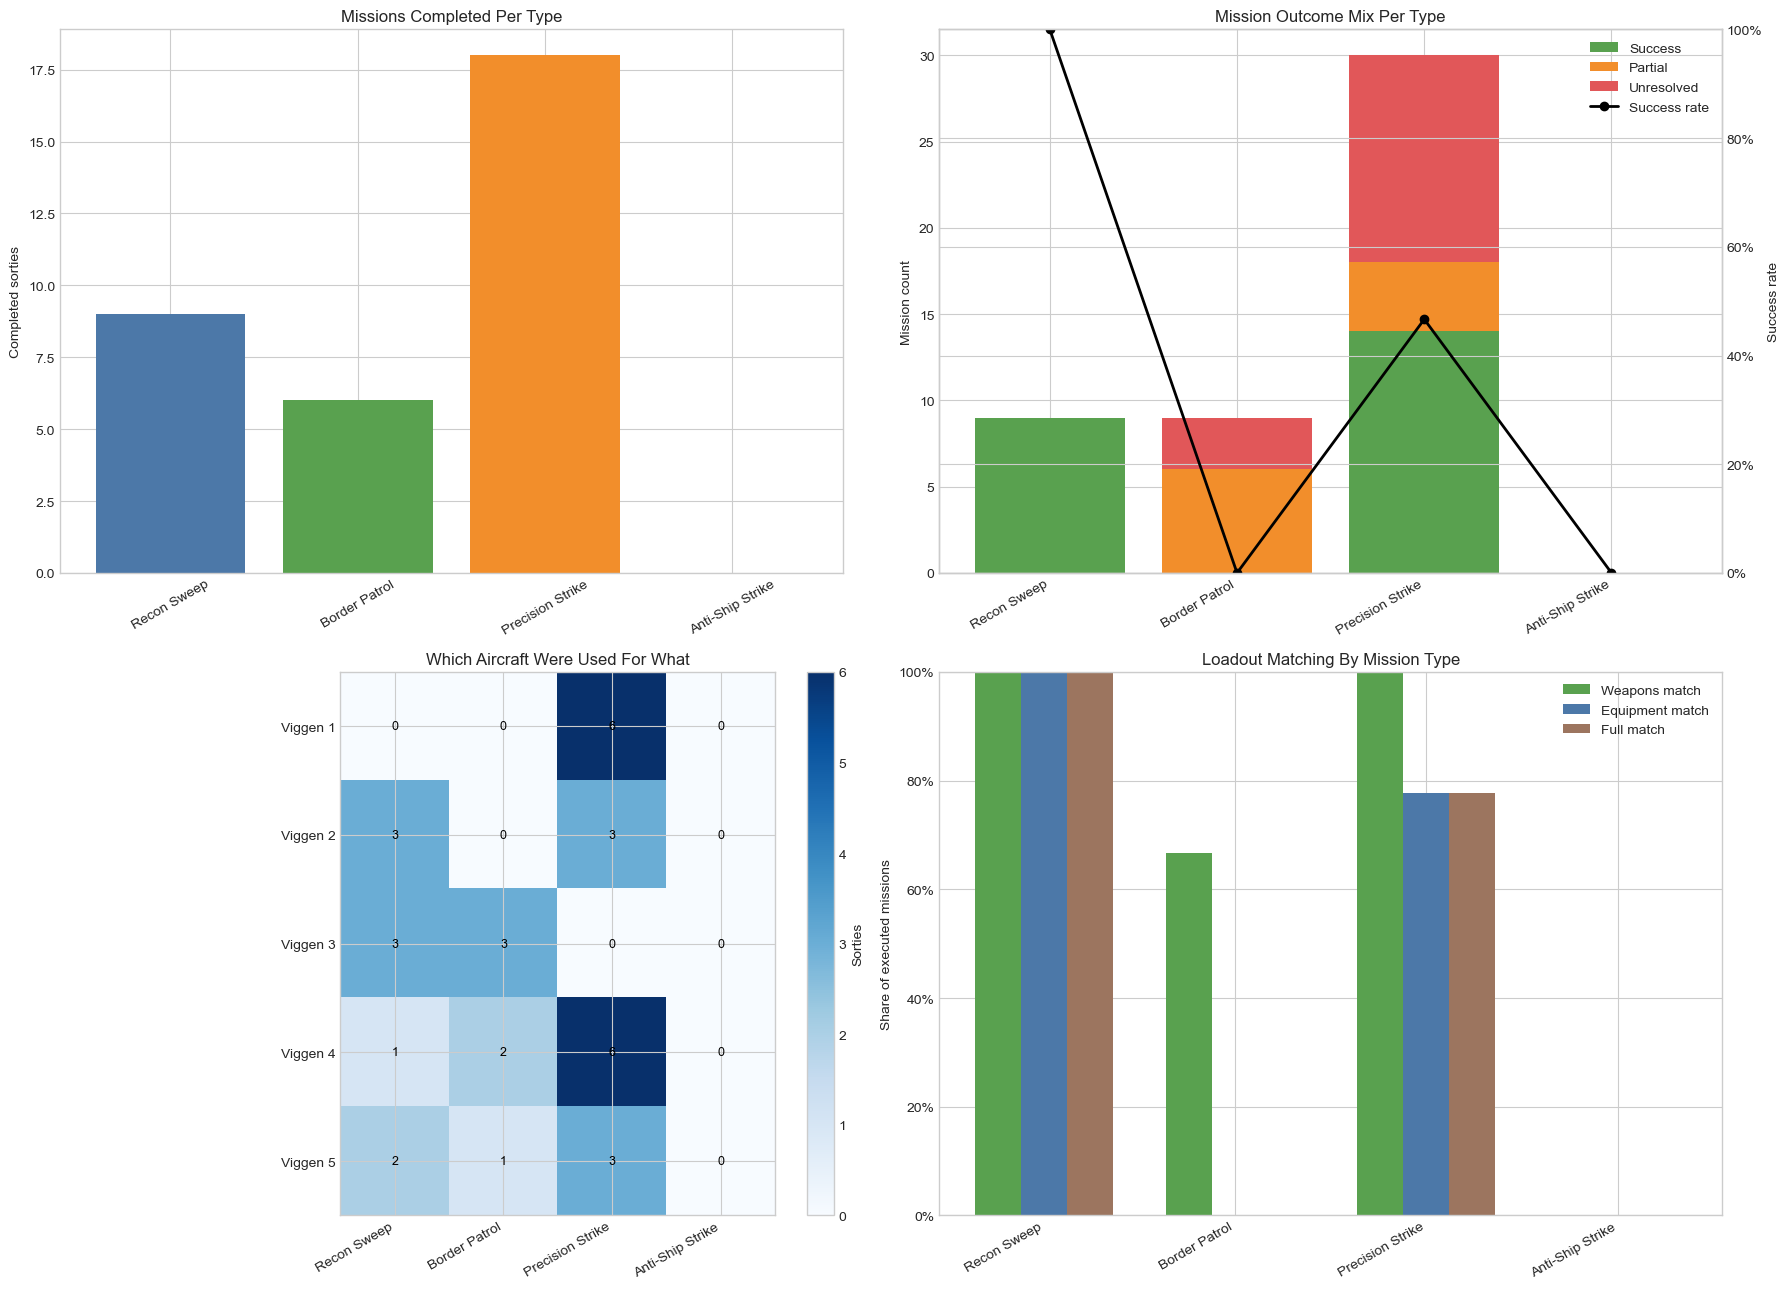

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 13))

ax = axes[0, 0]
if completed_by_type.sum() == 0:
    draw_no_data(ax, "Missions Completed Per Type")
else:
    ax.bar(
        MISSION_ORDER,
        completed_by_type.values,
        color=[MISSION_COLORS[name] for name in MISSION_ORDER],
    )
    ax.set_title("Missions Completed Per Type")
    ax.set_ylabel("Completed sorties")
    ax.tick_params(axis="x", rotation=30)

ax = axes[0, 1]
if mission_status[["offered", "success", "partial", "unresolved"]].to_numpy().sum() == 0:
    draw_no_data(ax, "Mission Outcome Mix Per Type")
else:
    x = np.arange(len(MISSION_ORDER))
    success = mission_status["success"].to_numpy()
    partial = mission_status["partial"].to_numpy()
    unresolved = mission_status["unresolved"].to_numpy()
    ax.bar(x, success, color="#59A14F", label="Success")
    ax.bar(x, partial, bottom=success, color="#F28E2B", label="Partial")
    ax.bar(x, unresolved, bottom=success + partial, color="#E15759", label="Unresolved")
    ax.set_xticks(x)
    ax.set_xticklabels(MISSION_ORDER, rotation=30, ha="right")
    ax.set_ylabel("Mission count")
    ax.set_title("Mission Outcome Mix Per Type")
    ax2 = ax.twinx()
    ax2.plot(x, mission_status["success_rate"].to_numpy(), color="black", marker="o", linewidth=2, label="Success rate")
    ax2.set_ylim(0, 1)
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.set_ylabel("Success rate")
    handles_1, labels_1 = ax.get_legend_handles_labels()
    handles_2, labels_2 = ax2.get_legend_handles_labels()
    ax.legend(handles_1 + handles_2, labels_1 + labels_2, loc="upper right")

ax = axes[1, 0]
if aircraft_mission_matrix.to_numpy().sum() == 0:
    draw_no_data(ax, "Which Aircraft Were Used For What")
else:
    heatmap = ax.imshow(aircraft_mission_matrix.values, cmap="Blues")
    ax.set_title("Which Aircraft Were Used For What")
    ax.set_xticks(np.arange(len(MISSION_ORDER)))
    ax.set_xticklabels(MISSION_ORDER, rotation=30, ha="right")
    ax.set_yticks(np.arange(len(AIRCRAFT_ORDER)))
    ax.set_yticklabels(AIRCRAFT_ORDER)
    for row_idx, aircraft_name in enumerate(AIRCRAFT_ORDER):
        for col_idx, mission_name in enumerate(MISSION_ORDER):
            value = int(aircraft_mission_matrix.loc[aircraft_name, mission_name])
            ax.text(col_idx, row_idx, value, ha="center", va="center", color="black", fontsize=9)
    fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04, label="Sorties")

ax = axes[1, 1]
if mission_exec_df.empty:
    draw_no_data(ax, "Loadout Matching By Mission Type")
else:
    x = np.arange(len(MISSION_ORDER))
    width = 0.24
    ax.bar(x - width, loadout_summary["weapon_match_rate"], width=width, color="#59A14F", label="Weapons match")
    ax.bar(x, loadout_summary["equipment_match_rate"], width=width, color="#4C78A8", label="Equipment match")
    ax.bar(x + width, loadout_summary["full_match_rate"], width=width, color="#9C755F", label="Full match")
    ax.set_xticks(x)
    ax.set_xticklabels(MISSION_ORDER, rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_ylabel("Share of executed missions")
    ax.set_title("Loadout Matching By Mission Type")
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


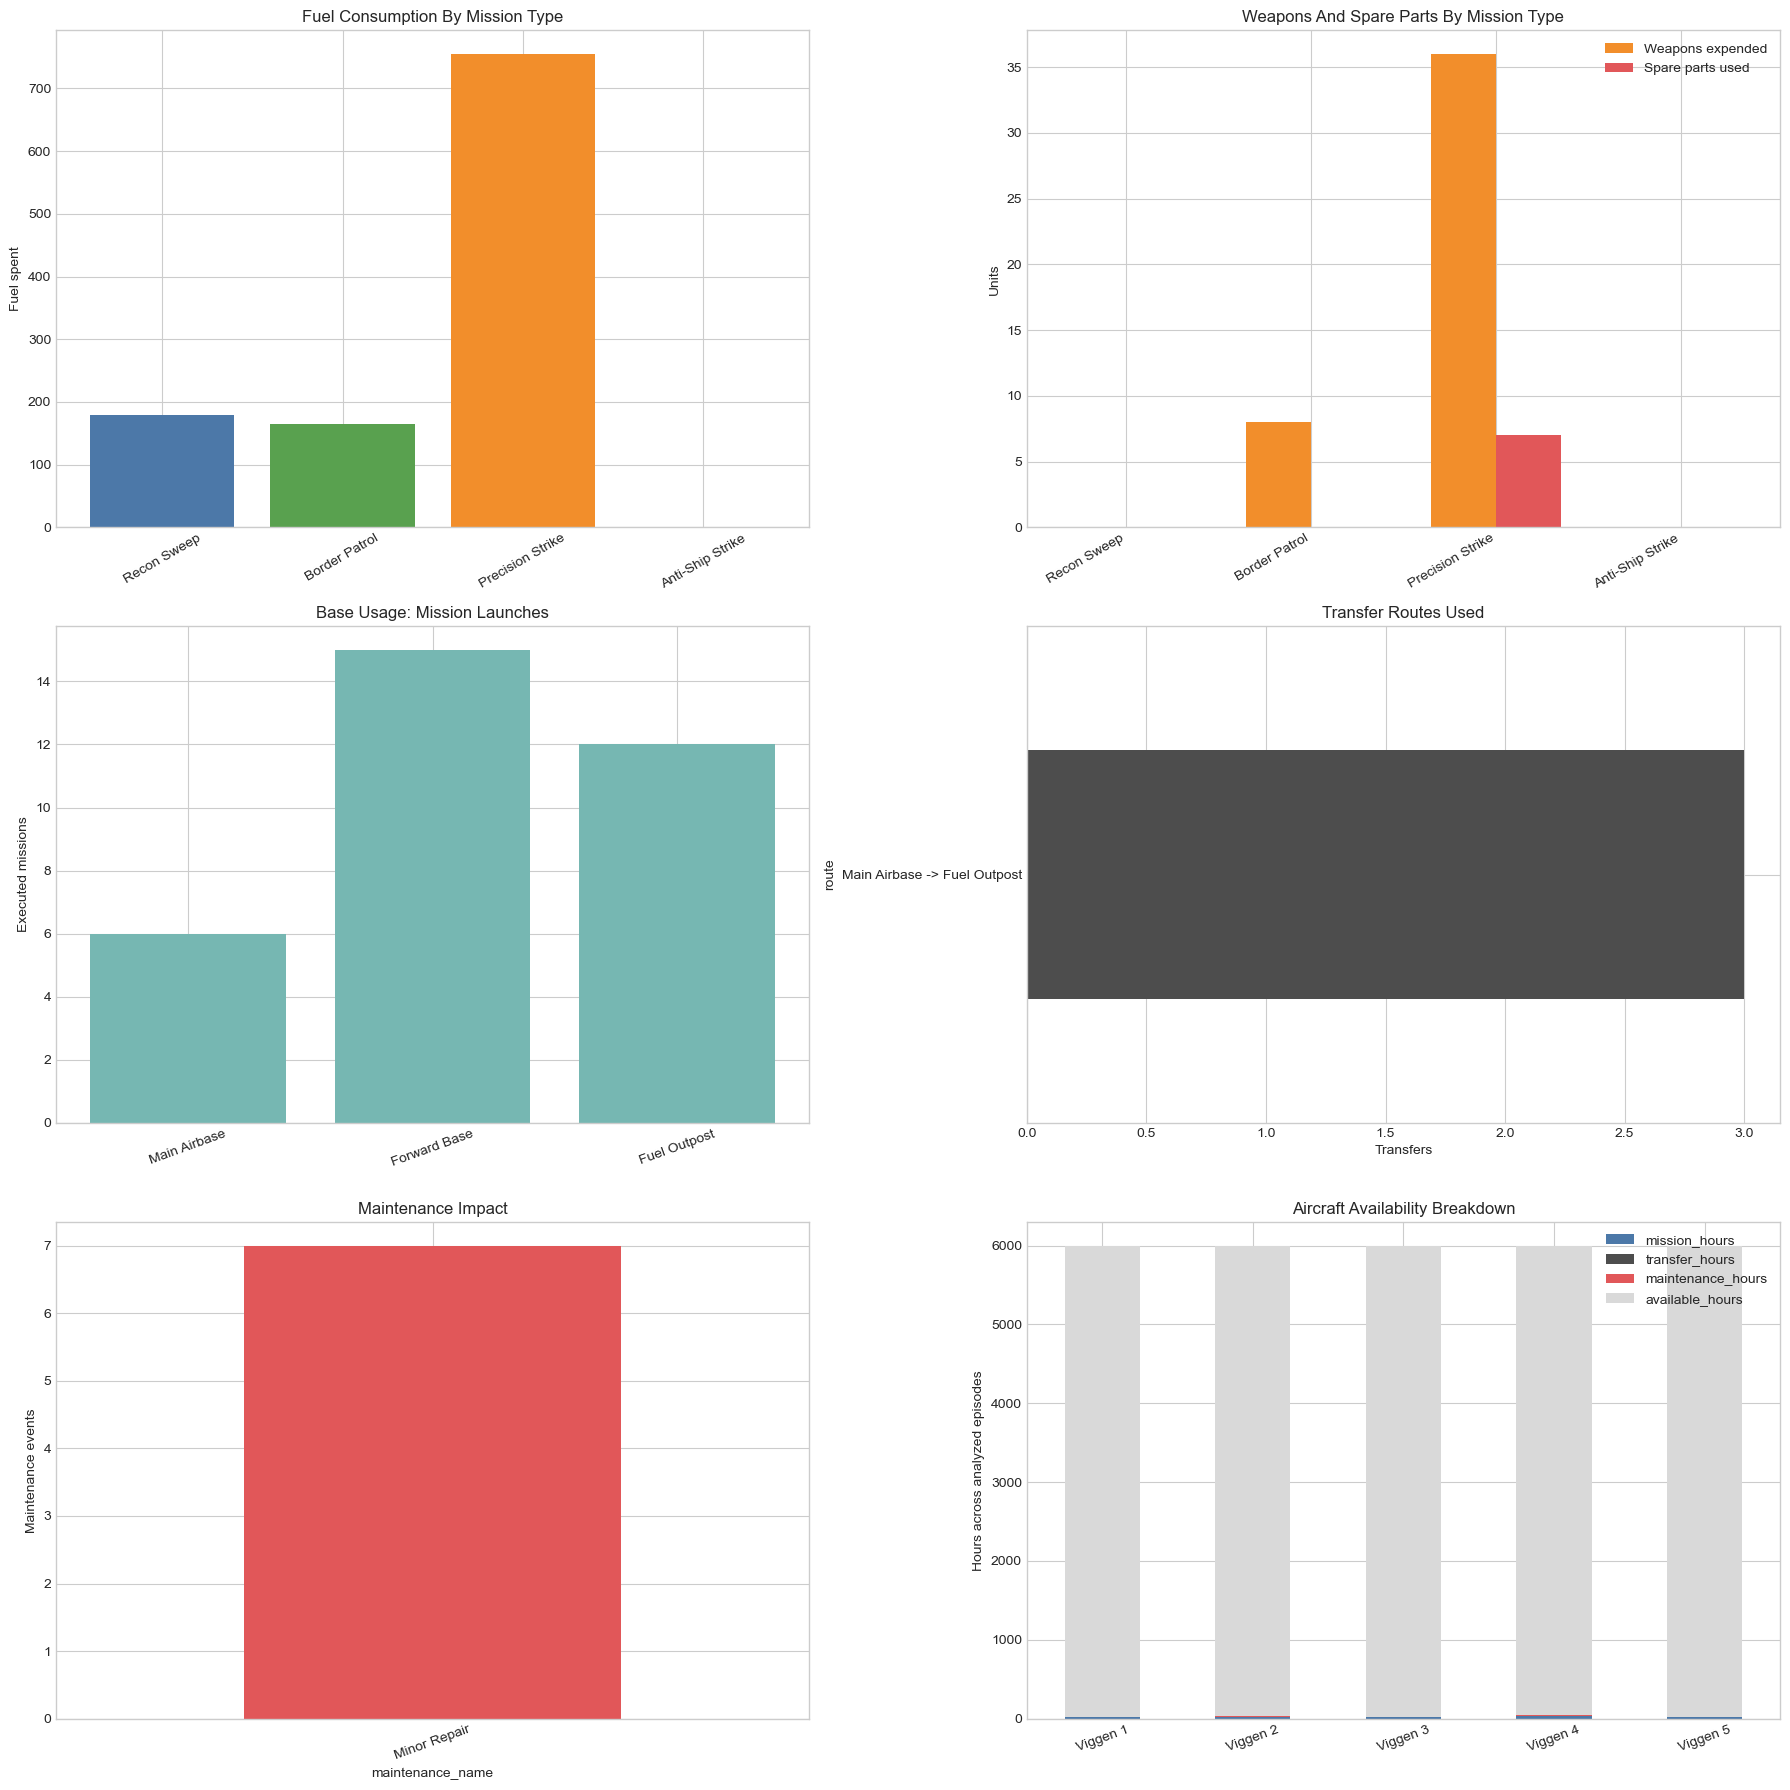

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(18, 18))

ax = axes[0, 0]
if resource_summary["fuel_used"].sum() == 0:
    draw_no_data(ax, "Fuel Consumption By Mission Type")
else:
    ax.bar(MISSION_ORDER, resource_summary["fuel_used"], color=[MISSION_COLORS[name] for name in MISSION_ORDER])
    ax.set_title("Fuel Consumption By Mission Type")
    ax.set_ylabel("Fuel spent")
    ax.tick_params(axis="x", rotation=30)

ax = axes[0, 1]
if resource_summary[["weapons_expended", "spare_parts_used"]].to_numpy().sum() == 0:
    draw_no_data(ax, "Weapons And Spare Parts By Mission Type")
else:
    x = np.arange(len(MISSION_ORDER))
    width = 0.35
    ax.bar(x - width / 2, resource_summary["weapons_expended"], width=width, color="#F28E2B", label="Weapons expended")
    ax.bar(x + width / 2, resource_summary["spare_parts_used"], width=width, color="#E15759", label="Spare parts used")
    ax.set_xticks(x)
    ax.set_xticklabels(MISSION_ORDER, rotation=30, ha="right")
    ax.set_title("Weapons And Spare Parts By Mission Type")
    ax.set_ylabel("Units")
    ax.legend(loc="upper right")

ax = axes[1, 0]
if sorties_by_base.sum() == 0:
    draw_no_data(ax, "Base Usage: Mission Launches")
else:
    ax.bar(sorties_by_base.index, sorties_by_base.values, color="#76B7B2")
    ax.set_title("Base Usage: Mission Launches")
    ax.set_ylabel("Executed missions")
    ax.tick_params(axis="x", rotation=20)

ax = axes[1, 1]
if transfer_routes.empty:
    draw_no_data(ax, "Transfer Routes Used")
else:
    transfer_routes.sort_values().plot(kind="barh", ax=ax, color="#4D4D4D")
    ax.set_title("Transfer Routes Used")
    ax.set_xlabel("Transfers")

ax = axes[2, 0]
if maintenance_counts.empty:
    draw_no_data(ax, "Maintenance Impact")
else:
    maintenance_counts.plot(kind="bar", ax=ax, color="#E15759")
    ax.set_title("Maintenance Impact")
    ax.set_ylabel("Maintenance events")
    ax.tick_params(axis="x", rotation=20)

ax = axes[2, 1]
if utilization.to_numpy().sum() == 0:
    draw_no_data(ax, "Aircraft Availability Breakdown")
else:
    utilization[["mission_hours", "transfer_hours", "maintenance_hours", "available_hours"]].plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=["#4C78A8", "#4D4D4D", "#E15759", "#D9D9D9"],
    )
    ax.set_title("Aircraft Availability Breakdown")
    ax.set_ylabel("Hours across analyzed episodes")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


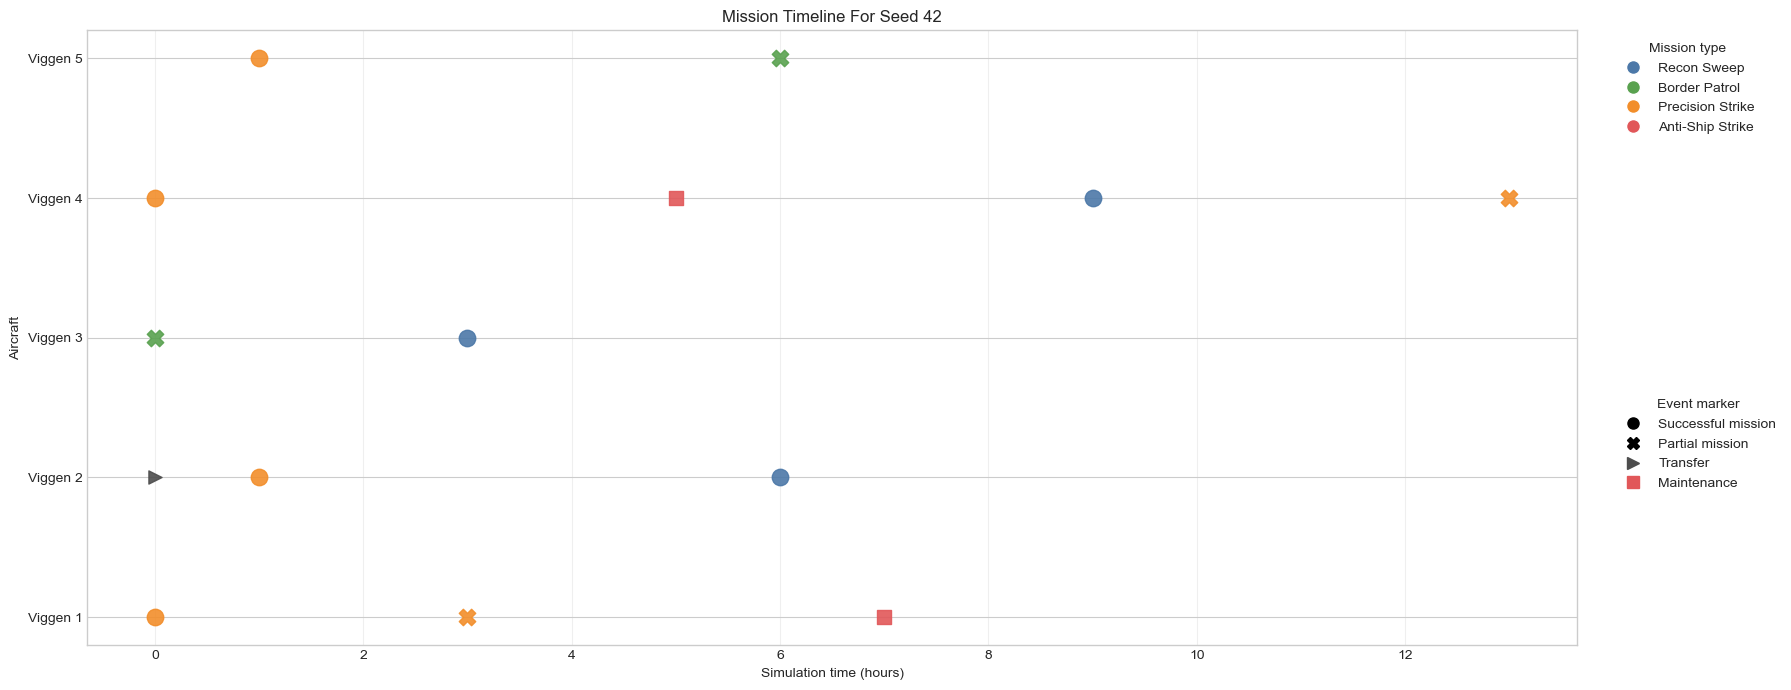

,time_hours,event_type,aircraft_name,mission_name,base_name,to_base_name,maintenance_name,outcome
0,0.0,mission_execution,Viggen 1,Precision Strike,Main Airbase,NaN,NaN,success
1,0.0,mission_execution,Viggen 3,Border Patrol,Forward Base,NaN,NaN,partial
2,0.0,mission_execution,Viggen 4,Precision Strike,Forward Base,NaN,NaN,success
3,0.0,mission_offered,NaN,Precision Strike,NaN,NaN,NaN,NaN
4,0.0,mission_offered,NaN,Precision Strike,NaN,NaN,NaN,NaN
5,0.0,mission_offered,NaN,Precision Strike,NaN,NaN,NaN,NaN
6,0.0,mission_offered,NaN,Border Patrol,NaN,NaN,NaN,NaN
7,0.0,mission_offered,NaN,Precision Strike,NaN,NaN,NaN,NaN
8,0.0,transfer,Viggen 2,NaN,NaN,Fuel Outpost,NaN,NaN
9,1.0,mission_execution,Viggen 2,Precision Strike,Fuel Outpost,NaN,NaN,success


In [5]:
timeline_events = timeline_df[timeline_df["event_type"].isin(["mission_execution", "transfer", "maintenance"])].copy()
timeline_events["aircraft_name"] = timeline_events["aircraft_name"].fillna("Unknown")
aircraft_to_y = {name: idx for idx, name in enumerate(AIRCRAFT_ORDER)}

fig, ax = plt.subplots(figsize=(18, 7))

mission_points = timeline_events[timeline_events["event_type"] == "mission_execution"]
for mission_name in MISSION_ORDER:
    for outcome, marker in [("success", "o"), ("partial", "X")]:
        subset = mission_points[
            (mission_points["mission_name"] == mission_name)
            & (mission_points["outcome"] == outcome)
        ]
        if subset.empty:
            continue
        ax.scatter(
            subset["time_hours"],
            subset["aircraft_name"].map(aircraft_to_y),
            s=140,
            marker=marker,
            color=MISSION_COLORS[mission_name],
            alpha=0.9,
        )

transfer_points = timeline_events[timeline_events["event_type"] == "transfer"]
if not transfer_points.empty:
    ax.scatter(
        transfer_points["time_hours"],
        transfer_points["aircraft_name"].map(aircraft_to_y),
        s=90,
        marker=">",
        color="#4D4D4D",
        alpha=0.9,
    )

maintenance_points = timeline_events[timeline_events["event_type"] == "maintenance"]
if not maintenance_points.empty:
    ax.scatter(
        maintenance_points["time_hours"],
        maintenance_points["aircraft_name"].map(aircraft_to_y),
        s=110,
        marker="s",
        color="#E15759",
        alpha=0.9,
    )

ax.set_yticks(np.arange(len(AIRCRAFT_ORDER)))
ax.set_yticklabels(AIRCRAFT_ORDER)
ax.set_xlabel("Simulation time (hours)")
ax.set_ylabel("Aircraft")
ax.set_title(f"Mission Timeline For Seed {TIMELINE_SEED}")
ax.grid(axis="x", alpha=0.3)

mission_handles = [
    Line2D([0], [0], marker="o", color="w", label=mission_name, markerfacecolor=MISSION_COLORS[mission_name], markersize=10)
    for mission_name in MISSION_ORDER
]
event_handles = [
    Line2D([0], [0], marker="o", color="black", label="Successful mission", linestyle="None", markersize=8),
    Line2D([0], [0], marker="X", color="black", label="Partial mission", linestyle="None", markersize=8),
    Line2D([0], [0], marker=">", color="#4D4D4D", label="Transfer", linestyle="None", markersize=8),
    Line2D([0], [0], marker="s", color="#E15759", label="Maintenance", linestyle="None", markersize=8),
]

legend_1 = ax.legend(handles=mission_handles, title="Mission type", bbox_to_anchor=(1.02, 1.0), loc="upper left")
ax.add_artist(legend_1)
ax.legend(handles=event_handles, title="Event marker", bbox_to_anchor=(1.02, 0.42), loc="upper left")

plt.tight_layout()
plt.show()

timeline_columns = [
    "time_hours",
    "event_type",
    "aircraft_name",
    "mission_name",
    "base_name",
    "to_base_name",
    "maintenance_name",
    "outcome",
]

available_columns = [column for column in timeline_columns if column in timeline_df.columns]
display(
    timeline_df[available_columns]
    .sort_values(["time_hours", "event_type"])
    .reset_index(drop=True)
    .head(25)
)
